In [1]:
import soundfile
import matplotlib.pyplot as plt
import numpy as np
import os

how_many = 1000

fbin = np.arange(0, 4000+10, 10)


path = './speech_commands_v0.01/go/'
files = [s for s in os.listdir(path) if s.endswith('.wav')]

Dgo = []
for s in files[:how_many]:
    data, samplerate = soundfile.read(path+s)
    A = np.abs(np.fft.rfft(data))
    freq = np.fft.rfftfreq(len(data), 1/samplerate)
    d = []
    for i in range(len(fbin)-1):
        d.append(A[np.logical_and(fbin[i] <= freq, freq <= fbin[i])].mean())
    Dgo.append(d)
Dgo = np.array(Dgo)
#Dgo[np.isnan(Dgo)] = 0
print(np.shape(Dgo))

path = './speech_commands_v0.01/left/'
files = [s for s in os.listdir(path) if s.endswith('.wav')]

Dleft = []
for s in files[:how_many]:
    data, samplerate = soundfile.read(path+s)
    A = np.abs(np.fft.rfft(data))
    freq = np.fft.rfftfreq(len(data), 1/samplerate)
    d = []
    for i in range(len(fbin)-1):
        d.append(A[np.logical_and(fbin[i] <= freq, freq <= fbin[i])].mean())
    Dleft.append(d)
Dleft = np.array(Dleft)
print(np.shape(Dleft))

path = './speech_commands_v0.01/no/'
files = [s for s in os.listdir(path) if s.endswith('.wav')]

Dno = []
for s in files[:how_many]:
    data, samplerate = soundfile.read(path+s)
    A = np.abs(np.fft.rfft(data))
    freq = np.fft.rfftfreq(len(data), 1/samplerate)
    d = []
    for i in range(len(fbin)-1):
        d.append(A[np.logical_and(fbin[i] <= freq, freq <= fbin[i])].mean())
    Dno.append(d)
Dno = np.array(Dno)
print(np.shape(Dno))

path = './speech_commands_v0.01/seven/'
files = [s for s in os.listdir(path) if s.endswith('.wav')]

Dseven = []
for s in files[:how_many]:
    data, samplerate = soundfile.read(path+s)
    A = np.abs(np.fft.rfft(data))
    freq = np.fft.rfftfreq(len(data), 1/samplerate)
    d = []
    for i in range(len(fbin)-1):
        d.append(A[np.logical_and(fbin[i] <= freq, freq <= fbin[i])].mean())
    Dseven.append(d)
Dseven = np.array(Dseven)
print(np.shape(Dseven))

path = './speech_commands_v0.01/yes/'
files = [s for s in os.listdir(path) if s.endswith('.wav')]

Dyes = []
for s in files[:how_many]:
    data, samplerate = soundfile.read(path+s)
    A = np.abs(np.fft.rfft(data))
    freq = np.fft.rfftfreq(len(data), 1/samplerate)
    d = []
    for i in range(len(fbin)-1):
        d.append(A[np.logical_and(fbin[i] <= freq, freq <= fbin[i])].mean())
    Dyes.append(d)
Dyes = np.array(Dyes)
print(np.shape(Dyes))

/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:21: RuntimeWarning: Mean of empty slice.
/anaconda3/lib/python3.7/site-packages/numpy/core/_methods.py:85: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


(1000, 400)


/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:37: RuntimeWarning: Mean of empty slice.


(1000, 400)


/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:52: RuntimeWarning: Mean of empty slice.


(1000, 400)


/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:67: RuntimeWarning: Mean of empty slice.


(1000, 400)


/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:82: RuntimeWarning: Mean of empty slice.


(1000, 400)


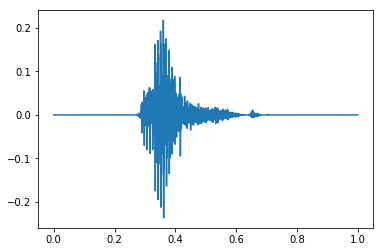

In [110]:
# Amplitude vs time plot

t = np.arange(len(data))/samplerate
plt.plot(t, data)

In [56]:
samplerate

16000

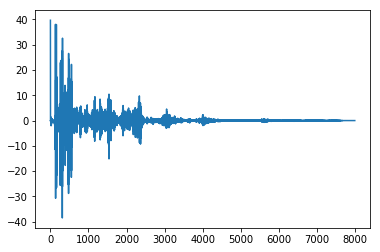

In [77]:
# Fourier transform to get amplitude vs frequency

y = np.fft.rfft(data)
x = np.fft.rfftfreq(len(data),1/samplerate)
plt.plot(x,y)
#plt.xlim(120,140)

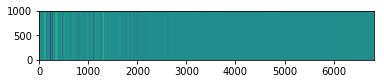

In [58]:
plt.imshow(np.real(y)*np.ones((1000,1)), origin = "lower")

In [2]:
# Training BDT

import xgboost as xgb

num_round = 1000
train = int(0.8*how_many)
test = int(0.2*how_many)

tot_train_data = np.concatenate((Dgo[:train],Dleft[:train],Dno[:train],Dseven[:train],Dyes[:train]))

a = np.full(train,1) # 1 corresponds to "go"
b = np.full(train,2) # 2 corresponds to "left"
c = np.full(train,3) # 3 corresponds to "no"
d = np.full(train,4) # 4 corresponds to "seven"
e = np.full(train,5) # 5 corresponds to "yes"

labels = np.concatenate((a,b,c,d,e))

dtrain = xgb.DMatrix(tot_train_data, label=labels)

tot_test_data = np.concatenate((Dgo[-test:], Dleft[-test:],Dno[-test:],Dseven[-test:],Dyes[-test:]))

dtest = xgb.DMatrix(tot_test_data)

param = {'max_depth':2, 'eta':1, 'silent':1}
bst = xgb.train(param, dtrain, num_round)
preds = bst.predict(dtest)

preds

array([ 2.9173217 ,  0.53883034,  2.205719  ,  2.10919   ,  1.5958152 ,
        2.573996  ,  0.7969069 , -0.24370587,  3.459517  ,  3.1105618 ,
        2.9975293 ,  1.2001867 ,  3.4628625 ,  2.6947253 ,  1.0228639 ,
        2.8353715 ,  1.2600434 ,  3.3593187 ,  3.1736176 ,  0.07536462,
        2.3153543 ,  2.7963367 ,  2.5490503 ,  4.507907  ,  1.856358  ,
        1.3542283 ,  0.7459003 ,  2.277307  ,  0.5858531 ,  4.270612  ,
        2.3459356 ,  0.70610493,  2.8409636 ,  2.0512438 ,  2.4689107 ,
        1.0983763 ,  1.1908003 ,  1.2162528 ,  4.1725435 ,  1.8941255 ,
        0.49882722, -0.03393173,  0.3511139 ,  2.9633055 ,  3.5255868 ,
        0.9710854 ,  2.0011435 ,  2.7935245 ,  3.6393387 ,  2.3834052 ,
        2.5593588 ,  3.1577716 ,  1.0481374 , -0.30745232,  2.2104948 ,
        1.3522387 ,  5.8144    ,  1.9089004 ,  1.6845595 ,  2.9146855 ,
        0.8520082 ,  3.903882  ,  4.92454   ,  2.5299606 ,  2.7289448 ,
        4.7698145 ,  4.939266  ,  0.98542345,  4.309903  ,  1.13

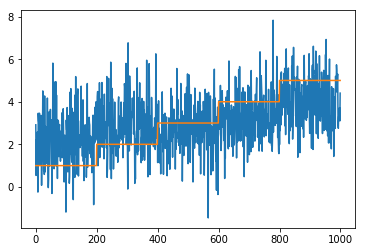

In [3]:
plt.plot(preds)

a = np.full(test,1) # 1 corresponds to "go"
b = np.full(test,2) # 0 corresponds to "left"
c = np.full(test,3) # 1 corresponds to "no"
d = np.full(test,4) # 0 corresponds to "seven"
e = np.full(test,5) # 1 corresponds to "yes"

labels = np.concatenate((a,b,c,d,e))

plt.plot(labels)

In [ ]:
# Test the efficiency
# Uncertainty
# What is the likelihood that these two curves are the same after accounting for "noise"


# Try changing the bin width, number of data points, number of iterations, etc and see how the bdt performs - least squares

# So far, by eye:
# - decreasing bin width did not have much effect
# - increasing size of training dataset made it much noisier, but you can definitely still see a slight rise from 1 to 5
# - increasing the number of iterations also doesn't make much of a difference...

# could I maybe find the best fit parameters for these??

In [142]:
len(preds)

1000

In [5]:
import speech_recognition as sr
from os import path
from pydub import AudioSegment

# convert mp3 file to wav  

# sound = AudioSegment.from_mp3("transcript.mp3")
# sound.export("transcript.wav", format="wav")
# AUDIO_FILE = "transcript.wav"


AUDIO_FILE = './speech_commands_v0.01/go/ffd2ba2f_nohash_1.wav'


# use the audio file as the audio source
r = sr.Recognizer()
with sr.AudioFile(AUDIO_FILE) as source:
        audio = r.record(source)  # read the entire audio file                  

        print("Transcription: " + r.recognize_google(audio))

Transcription: call


In [13]:
path = './speech_commands_v0.01/house/'
files = [s for s in os.listdir(path) if s.endswith('.wav')]

r = sr.Recognizer()
how_many = 5

transcription = []
for s in files[:how_many]:
    AUDIO_FILE = path + s
    with sr.AudioFile(AUDIO_FILE) as source:
        audio = r.record(source)  # read the entire audio file                  

        print("Transcription: " + r.recognize_google(audio))

Transcription: house
Transcription: house
Transcription: house
Transcription: house
Transcription: house


In [18]:
AUDIO_FILE = "OSR_us_000_0010_8k.wav"
with sr.AudioFile(AUDIO_FILE) as source:
    audio = r.record(source)  # read the entire audio file
    print("Transcription: " + r.recognize_google(audio))

Transcription: the birch canoes Madonna smooth pranks glue the sea to the dark blue background it is easy to tell the depth of a well these days a chicken Leg is a radish rice is often served in rambles the juice of lemons makes fine punch the box was down beside the park chuck the houses which have corn and garbage 4 hours of study work faced as a large thighs in stockings is hard to sell


In [22]:
sound = AudioSegment.from_mp3("19-198-0000.flac")
sound.export("19-198-0000.wav", format="wav")

CouldntDecodeError: Decoding failed. ffmpeg returned error code: 1

Output from ffmpeg/avlib:

b"ffmpeg version 4.1.2 Copyright (c) 2000-2019 the FFmpeg developers\n  built with Apple LLVM version 10.0.0 (clang-1000.11.45.5)\n  configuration: --prefix=/usr/local/Cellar/ffmpeg/4.1.2 --enable-shared --enable-pthreads --enable-version3 --enable-hardcoded-tables --enable-avresample --cc=clang --host-cflags='-I/Library/Java/JavaVirtualMachines/openjdk-11.0.2.jdk/Contents/Home/include -I/Library/Java/JavaVirtualMachines/openjdk-11.0.2.jdk/Contents/Home/include/darwin' --host-ldflags= --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libbluray --enable-libmp3lame --enable-libopus --enable-librubberband --enable-libsnappy --enable-libtesseract --enable-libtheora --enable-libvorbis --enable-libvpx --enable-libx264 --enable-libx265 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-lib

In [21]:
import ftransc

ftransc -f flac "19-198-0000.flac".wav

SyntaxError: invalid syntax (<ipython-input-21-2a97b53075e6>, line 3)

In [2]:
#!/usr/bin/env python3
import numpy as np
import librosa
import os

X = []
y = []
nn = []
for i, path in enumerate(["stop", "go", "yes"]):
    path = os.path.join('./speech_commands_v0.01/', path)
    for s in [dum for dum in os.listdir(path) if dum.endswith('.wav')]:
            print(os.path.join(path, s))
            wave, sr = librosa.load(os.path.join(path, s))
            mfcc = librosa.feature.mfcc(wave, sr)
            nn.append(mfcc.shape[0])
            X.append(mfcc)
            y.append(i)

X_pad = [np.pad(mfcc, pad_width=((0, 0), (0, np.max(nn)-mfcc.shape[1])), mode='constant') for mfcc in X]
np.save('datax', X_pad)
np.save('datay', y)


./speech_commands_v0.01/stop/988e2f9a_nohash_0.wav
./speech_commands_v0.01/stop/1eddce1d_nohash_3.wav
./speech_commands_v0.01/stop/439c84f4_nohash_1.wav
./speech_commands_v0.01/stop/6a27a9bf_nohash_0.wav
./speech_commands_v0.01/stop/b87bdb22_nohash_1.wav
./speech_commands_v0.01/stop/97f4c236_nohash_2.wav
./speech_commands_v0.01/stop/a9abc695_nohash_1.wav
./speech_commands_v0.01/stop/563aa4e6_nohash_2.wav
./speech_commands_v0.01/stop/51055bda_nohash_4.wav
./speech_commands_v0.01/stop/a8cb6dda_nohash_0.wav
./speech_commands_v0.01/stop/5fe4a278_nohash_0.wav
./speech_commands_v0.01/stop/dabf67d9_nohash_0.wav
./speech_commands_v0.01/stop/742d6431_nohash_3.wav
./speech_commands_v0.01/stop/62581901_nohash_0.wav
./speech_commands_v0.01/stop/68dd409e_nohash_1.wav
./speech_commands_v0.01/stop/5184ed3e_nohash_1.wav
./speech_commands_v0.01/stop/bf8d5617_nohash_0.wav
./speech_commands_v0.01/stop/7ff085e1_nohash_0.wav
./speech_commands_v0.01/stop/d9b50b8b_nohash_1.wav
./speech_commands_v0.01/stop/22

./speech_commands_v0.01/stop/742d6431_nohash_0.wav
./speech_commands_v0.01/stop/68dd409e_nohash_2.wav
./speech_commands_v0.01/stop/b87bdb22_nohash_2.wav
./speech_commands_v0.01/stop/97f4c236_nohash_1.wav
./speech_commands_v0.01/stop/86402da1_nohash_0.wav
./speech_commands_v0.01/stop/563aa4e6_nohash_1.wav
./speech_commands_v0.01/stop/229978fd_nohash_0.wav
./speech_commands_v0.01/stop/a24582a0_nohash_0.wav
./speech_commands_v0.01/stop/5184ed3e_nohash_2.wav
./speech_commands_v0.01/stop/8a28231e_nohash_0.wav
./speech_commands_v0.01/stop/65c73b55_nohash_0.wav
./speech_commands_v0.01/stop/8012c69d_nohash_0.wav
./speech_commands_v0.01/stop/686d030b_nohash_2.wav
./speech_commands_v0.01/stop/dbaf8fc6_nohash_1.wav
./speech_commands_v0.01/stop/8134f43f_nohash_3.wav
./speech_commands_v0.01/stop/9b402bc2_nohash_0.wav
./speech_commands_v0.01/stop/f33660af_nohash_0.wav
./speech_commands_v0.01/stop/57376a4c_nohash_2.wav
./speech_commands_v0.01/stop/a6d586b7_nohash_2.wav
./speech_commands_v0.01/stop/9a

./speech_commands_v0.01/stop/27b9a84f_nohash_1.wav
./speech_commands_v0.01/stop/7fd25f7c_nohash_4.wav
./speech_commands_v0.01/stop/46a153d8_nohash_3.wav
./speech_commands_v0.01/stop/e71b4ce6_nohash_0.wav
./speech_commands_v0.01/stop/692a88e6_nohash_1.wav
./speech_commands_v0.01/stop/3402e488_nohash_2.wav
./speech_commands_v0.01/stop/88f3719f_nohash_2.wav
./speech_commands_v0.01/stop/d90b4138_nohash_2.wav
./speech_commands_v0.01/stop/5b09db89_nohash_3.wav
./speech_commands_v0.01/stop/b665723d_nohash_0.wav
./speech_commands_v0.01/stop/8335f893_nohash_1.wav
./speech_commands_v0.01/stop/bdee441c_nohash_1.wav
./speech_commands_v0.01/stop/22aa3665_nohash_1.wav
./speech_commands_v0.01/stop/e900b652_nohash_0.wav
./speech_commands_v0.01/stop/888a0c49_nohash_2.wav
./speech_commands_v0.01/stop/e41a903b_nohash_1.wav
./speech_commands_v0.01/stop/eb6dab4a_nohash_0.wav
./speech_commands_v0.01/stop/5af0ca83_nohash_1.wav
./speech_commands_v0.01/stop/7ea032f3_nohash_0.wav
./speech_commands_v0.01/stop/b7

./speech_commands_v0.01/stop/d90b4138_nohash_1.wav
./speech_commands_v0.01/stop/1ed557b9_nohash_0.wav
./speech_commands_v0.01/stop/3402e488_nohash_1.wav
./speech_commands_v0.01/stop/88f3719f_nohash_1.wav
./speech_commands_v0.01/stop/692a88e6_nohash_2.wav
./speech_commands_v0.01/stop/9e42ae25_nohash_0.wav
./speech_commands_v0.01/stop/80c45ed6_nohash_1.wav
./speech_commands_v0.01/stop/5b09db89_nohash_0.wav
./speech_commands_v0.01/stop/5236848b_nohash_0.wav
./speech_commands_v0.01/stop/4bb1244f_nohash_1.wav
./speech_commands_v0.01/stop/bdee441c_nohash_2.wav
./speech_commands_v0.01/stop/035de8fe_nohash_0.wav
./speech_commands_v0.01/stop/7ea032f3_nohash_3.wav
./speech_commands_v0.01/stop/d2f4f431_nohash_1.wav
./speech_commands_v0.01/stop/eb3f7d82_nohash_4.wav
./speech_commands_v0.01/stop/3a182c98_nohash_0.wav
./speech_commands_v0.01/stop/888a0c49_nohash_1.wav
./speech_commands_v0.01/stop/e41a903b_nohash_2.wav
./speech_commands_v0.01/stop/de41f895_nohash_0.wav
./speech_commands_v0.01/stop/cc

./speech_commands_v0.01/stop/01bb6a2a_nohash_1.wav
./speech_commands_v0.01/stop/4e8c5516_nohash_0.wav
./speech_commands_v0.01/stop/763188c4_nohash_0.wav
./speech_commands_v0.01/stop/234ab0fb_nohash_0.wav
./speech_commands_v0.01/stop/27c30960_nohash_1.wav
./speech_commands_v0.01/stop/0c2d2ffa_nohash_0.wav
./speech_commands_v0.01/stop/27c30960_nohash_0.wav
./speech_commands_v0.01/stop/743edf9d_nohash_0.wav
./speech_commands_v0.01/stop/a7dd45cf_nohash_0.wav
./speech_commands_v0.01/stop/11860c84_nohash_2.wav
./speech_commands_v0.01/stop/763188c4_nohash_1.wav
./speech_commands_v0.01/stop/b9cccd01_nohash_0.wav
./speech_commands_v0.01/stop/8b39e36f_nohash_1.wav
./speech_commands_v0.01/stop/01bb6a2a_nohash_0.wav
./speech_commands_v0.01/stop/9ff2d2f4_nohash_1.wav
./speech_commands_v0.01/stop/3ff840aa_nohash_0.wav
./speech_commands_v0.01/stop/e07dd7d4_nohash_2.wav
./speech_commands_v0.01/stop/1e412fac_nohash_0.wav
./speech_commands_v0.01/stop/b1426003_nohash_0.wav
./speech_commands_v0.01/stop/e5

...

./speech_commands_v0.01/yes/c93d5e22_nohash_0.wav
./speech_commands_v0.01/yes/77def3ee_nohash_0.wav
./speech_commands_v0.01/yes/7c1d8533_nohash_2.wav
./speech_commands_v0.01/yes/94de6a6a_nohash_0.wav
./speech_commands_v0.01/yes/ffbb695d_nohash_0.wav
./speech_commands_v0.01/yes/72d75d96_nohash_0.wav
./speech_commands_v0.01/yes/ffbb695d_nohash_1.wav
./speech_commands_v0.01/yes/7c1d8533_nohash_3.wav
./speech_commands_v0.01/yes/77def3ee_nohash_1.wav
./speech_commands_v0.01/yes/c93d5e22_nohash_1.wav
./speech_commands_v0.01/yes/28ed6bc9_nohash_4.wav
./speech_commands_v0.01/yes/bc196f81_nohash_1.wav
./speech_commands_v0.01/yes/94de6a6a_nohash_1.wav
./speech_commands_v0.01/yes/ced835d3_nohash_3.wav
./speech_commands_v0.01/yes/5828dfa2_nohash_0.wav
./speech_commands_v0.01/yes/da584bc0_nohash_1.wav
./speech_commands_v0.01/yes/b9f46737_nohash_3.wav
./speech_commands_v0.01/yes/656e8bb3_nohash_0.wav
./speech_commands_v0.01/yes/2df590cd_nohash_0.wav
./speech_commands_v0.01/yes/ec5ab5d5_nohash_0.wav


./speech_commands_v0.01/yes/27b03931_nohash_0.wav
./speech_commands_v0.01/yes/1cc80e39_nohash_1.wav
./speech_commands_v0.01/yes/151bfb79_nohash_1.wav
./speech_commands_v0.01/yes/ced835d3_nohash_0.wav
./speech_commands_v0.01/yes/353b4d33_nohash_0.wav
./speech_commands_v0.01/yes/2aa787cf_nohash_0.wav
./speech_commands_v0.01/yes/64da5281_nohash_0.wav
./speech_commands_v0.01/yes/2cec1d47_nohash_0.wav
./speech_commands_v0.01/yes/b9f46737_nohash_0.wav
./speech_commands_v0.01/yes/da584bc0_nohash_2.wav
./speech_commands_v0.01/yes/6736bc64_nohash_1.wav
./speech_commands_v0.01/yes/311fde72_nohash_1.wav
./speech_commands_v0.01/yes/173e6bbf_nohash_0.wav
./speech_commands_v0.01/yes/92a9c5e6_nohash_3.wav
./speech_commands_v0.01/yes/611d2b50_nohash_1.wav
./speech_commands_v0.01/yes/b83c1acf_nohash_4.wav
./speech_commands_v0.01/yes/dc2222d7_nohash_0.wav
./speech_commands_v0.01/yes/977a3be4_nohash_0.wav
./speech_commands_v0.01/yes/f953e1af_nohash_1.wav
./speech_commands_v0.01/yes/92e17cc4_nohash_0.wav


./speech_commands_v0.01/yes/c8db14a8_nohash_2.wav
./speech_commands_v0.01/yes/f7879738_nohash_0.wav
./speech_commands_v0.01/yes/0685264e_nohash_1.wav
./speech_commands_v0.01/yes/3bfd30e6_nohash_3.wav
./speech_commands_v0.01/yes/28ed6bc9_nohash_2.wav
./speech_commands_v0.01/yes/dd6c6806_nohash_0.wav
./speech_commands_v0.01/yes/8e05039f_nohash_1.wav
./speech_commands_v0.01/yes/82b99576_nohash_1.wav
./speech_commands_v0.01/yes/611d2b50_nohash_4.wav
./speech_commands_v0.01/yes/b83c1acf_nohash_1.wav
./speech_commands_v0.01/yes/6c9223bd_nohash_0.wav
./speech_commands_v0.01/yes/d197e3ae_nohash_0.wav
./speech_commands_v0.01/yes/0135f3f2_nohash_0.wav
./speech_commands_v0.01/yes/3cdecb0b_nohash_0.wav
./speech_commands_v0.01/yes/cce17a61_nohash_0.wav
./speech_commands_v0.01/yes/7d86b703_nohash_0.wav
./speech_commands_v0.01/yes/80f056c0_nohash_0.wav
./speech_commands_v0.01/yes/1aeef15e_nohash_2.wav
./speech_commands_v0.01/yes/e5afa9b0_nohash_0.wav
./speech_commands_v0.01/yes/2bdbe5f7_nohash_3.wav


./speech_commands_v0.01/yes/f550b7dc_nohash_0.wav
./speech_commands_v0.01/yes/b3bb4dd6_nohash_0.wav
./speech_commands_v0.01/yes/1aeef15e_nohash_1.wav
./speech_commands_v0.01/yes/a0f93943_nohash_1.wav
./speech_commands_v0.01/yes/ab7b5acd_nohash_0.wav
./speech_commands_v0.01/yes/baeac2ba_nohash_3.wav
./speech_commands_v0.01/yes/33246bc2_nohash_0.wav
./speech_commands_v0.01/yes/28ce0c58_nohash_3.wav
./speech_commands_v0.01/yes/f264e0df_nohash_1.wav
./speech_commands_v0.01/yes/b63fea9e_nohash_0.wav
./speech_commands_v0.01/yes/e48a80ed_nohash_0.wav
./speech_commands_v0.01/yes/e7334395_nohash_1.wav
./speech_commands_v0.01/yes/7c75a504_nohash_0.wav
./speech_commands_v0.01/yes/617de221_nohash_2.wav
./speech_commands_v0.01/yes/d0faf7e4_nohash_0.wav
./speech_commands_v0.01/yes/b4aa9fef_nohash_2.wav
./speech_commands_v0.01/yes/8494fba8_nohash_0.wav
./speech_commands_v0.01/yes/e649aa92_nohash_0.wav
./speech_commands_v0.01/yes/d85270c1_nohash_0.wav
./speech_commands_v0.01/yes/e7ea8b76_nohash_0.wav


ValueError: ((0, 0), (0, -24)) cannot contain negative values.

In [2]:
y

NameError: name 'y' is not defined

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D
from keras.utils import to_categorical
import matplotlib.pyplot as plt


np.random.seed(1)

#X = np.load('./audio-cats-and-dogs/datax.npy')
X = np.load('datax.npy')
y = np.load('datay.npy')


X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.8)

X_train = X_train.reshape(*X_train.shape, 1)
X_test = X_test.reshape(*X_test.shape, 1)
y_train_hot = to_categorical(y_train)
y_test_hot = to_categorical(y_test)

y_train_hot = to_categorical(y_train)
y_test_hot = to_categorical(y_test)

model = Sequential()
#model.add(Conv2D(32, kernel_size=3, activation='tanh', input_shape=X_train.shape[1:])) # "relu" instead of tanh
#model.add(Conv2D(16, kernel_size=3, activation='tanh'))
model.add(Flatten())
#model.add(Dense(128, activation='tanh'))
model.add(Dense(128, activation='tanh'))
model.add(Dense(3, activation='softmax'))

model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=keras.optimizers.adam(),
              metrics=['accuracy'])
h = model.fit(X_train, y_train_hot, batch_size=200, epochs=50, verbose=1, validation_data=(X_test, y_test_hot))

plt.plot(h.history['acc'], color = "red", label = "Train")
plt.plot(h.history['val_acc'], color = "black", label = "Test")
plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

test_loss, test_acc = model.evaluate(X_test, y_test_hot)

print('Test accuracy:', test_acc)


Using TensorFlow backend.


ModuleNotFoundError: No module named 'numpy.core._multiarray_umath'

SystemError: <class '_frozen_importlib._ModuleLockManager'> returned a result with an error set

ImportError: numpy.core._multiarray_umath failed to import

ImportError: numpy.core.umath failed to import

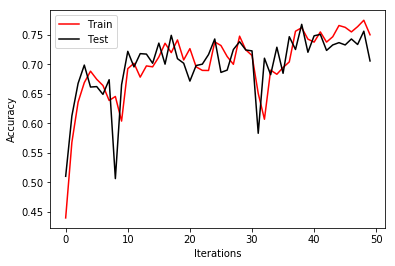

In [4]:
plt.plot(h.history['acc'], color = "red", label = "Train")
plt.plot(h.history['val_acc'], color = "black", label = "Test")
plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Train on 5155 samples, validate on 1289 samples
Epoch 1/25
5155/5155 [==============================] - 71s 14ms/step - loss: 0.8317 - acc: 0.6481 - val_loss: 0.5927 - val_acc: 0.7673
Epoch 2/25
5155/5155 [==============================] - 70s 14ms/step - loss: 0.5275 - acc: 0.7975 - val_loss: 0.5673 - val_acc: 0.7843
Epoch 3/25
5155/5155 [==============================] - 74s 14ms/step - loss: 0.4330 - acc: 0.8343 - val_loss: 0.5073 - val_acc: 0.7960
Epoch 4/25
5155/5155 [==============================] - 73s 14ms/step - loss: 0.3652 - acc: 0.8727 - val_loss: 0.4864 - val_acc: 0.8231
Epoch 5/25
5155/5155 [==============================] - 68s 13ms/step - loss: 0.3094 - acc: 0.8989 - val_loss: 0.4725 - val_acc: 0.8146
Epoch 6/25
5155/5155 [==============================] - 69s 13ms/step - loss: 0.2533 - acc: 0.9242 - val_loss: 0.4970 - val_acc: 0.8014
Epoch 7/25
5155/5155 [==============================] - 69s 13ms/step - loss: 0.2107 - acc: 0.9455 - val_loss: 0.4687 - val_acc: 0.8115


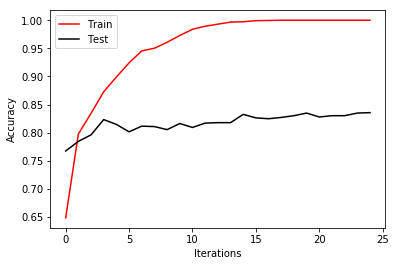

1289/1289 [==============================] - 6s 4ms/step
Test accuracy: 0.8355314197051978


In [11]:
from sklearn.model_selection import train_test_split
import numpy as np
import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D
from keras.utils import to_categorical
import matplotlib.pyplot as plt
from keras.models import load_model


np.random.seed(1)

#X = np.load('./audio-cats-and-dogs/datax.npy')
X = np.load('datax.npy')
y = np.load('datay.npy')


X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.8)

X_train = X_train.reshape(*X_train.shape, 1)
X_test = X_test.reshape(*X_test.shape, 1)
y_train_hot = to_categorical(y_train)
y_test_hot = to_categorical(y_test)

y_train_hot = to_categorical(y_train)
y_test_hot = to_categorical(y_test)

model = Sequential()
model.add(Conv2D(32, kernel_size=3, activation='tanh', input_shape=X_train.shape[1:])) # "relu" instead of tanh
model.add(Conv2D(16, kernel_size=3, activation='tanh'))
model.add(Flatten())
#model.add(Dense(128, activation='tanh'))
#model.add(Dense(128, activation='tanh'))
model.add(Dense(3, activation='softmax'))

model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=keras.optimizers.adam(),
              metrics=['accuracy'])

# model.save('my_model.h5')  # creates a HDF5 file 'my_model.h5'

h = model.fit(X_train, y_train_hot, batch_size=200, epochs=25, verbose=1, validation_data=(X_test, y_test_hot))

data = [model.predict(X_test), y_test_hot, h.history['acc'], h.history['val_acc']]

np.save('trained', data)


plt.plot(h.history['acc'], color = "red", label = "Train")
plt.plot(h.history['val_acc'], color = "black", label = "Test")
plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

test_loss, test_acc = model.evaluate(X_test, y_test_hot)

print('Test accuracy:', test_acc)


In [12]:
X_test = X_test.take(y_test.argsort(), axis=0)
y_test_hot = to_categorical(np.sort(y_test))
data = [model.predict(X_test), y_test_hot, h.history['acc'], h.history['val_acc']]
np.save('trained', data)

In [13]:
np.save('X_test', X_test)
np.save('X_train', X_train)
np.save('y_test_hot', y_test_hot)
np.save('y_train_hot', y_train_hot)

In [48]:
import copy
h0 = copy.deepcopy(h)


In [17]:
from sklearn.model_selection import train_test_split
import numpy as np
import xgboost as xgb

num_round = 50

X = np.load('datax.npy')
y = np.load('datay.npy')

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.8)


tot_train_data = X_train.reshape(len(X_train),20*1000)

labels = y_train

dtrain = xgb.DMatrix(tot_train_data, label=labels)

tot_test_data = X_test.reshape(len(X_test),20*1000)

dtest = xgb.DMatrix(tot_test_data)

param = {'max_depth':2, 'eta':1, 'silent':1}
bst = xgb.train(param, dtrain, num_round)
preds = bst.predict(dtest)

from sklearn.metrics import accuracy_score

new = [round(value) for value in preds]
accuracy_score(y_test, new)

/anaconda3/lib/python3.6/site-packages/sklearn/model_selection/_split.py:2179: FutureWarning: From version 0.21, test_size will always complement train_size unless both are specified.
  FutureWarning)


0.5725368502715283

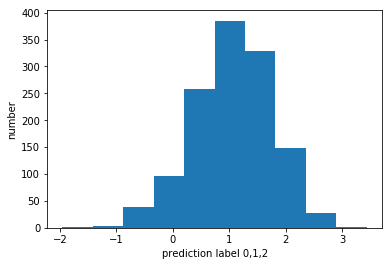

In [18]:
import matplotlib.pyplot as plt
plt.hist(preds)
plt.xlabel("prediction label 0,1,2")
plt.ylabel("number")
plt.show()

In [16]:
len([ele for ele in preds if ele == 0])

0

(0, 500)

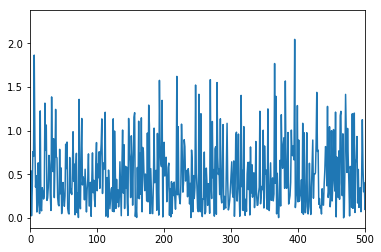

In [9]:
plt.plot(abs(preds-y_test))
#plt.plot(y_test)
plt.xlim(0,500)

In [36]:
s =np.abs(preds-y_test)
s[~np.isclose(s, 0)] = 1
s.sum()
preds

array([0.03145832, 1.460295  , 0.97520864, ..., 1.1007507 , 0.9668628 ,
       1.2499696 ], dtype=float32)

0.5795190069821567

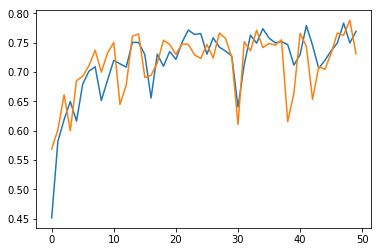

In [10]:
plt.plot(h.history['acc'])
plt.plot(h.history['val_acc'])
plt.show()

In [17]:
X.shape

(6444, 20, 1000)

In [19]:
X.reshape(6444,20*1000)

array([[-546.90840237, -550.17672898, -552.71346667, ...,    0.        ,
           0.        ,    0.        ],
       [-372.10927326, -374.54964811, -374.96105333, ...,    0.        ,
           0.        ,    0.        ],
       [-420.41660824, -417.00596724, -425.17234391, ...,    0.        ,
           0.        ,    0.        ],
       ...,
       [-159.94142043, -158.03160068, -154.67039964, ...,    0.        ,
           0.        ,    0.        ],
       [-619.82654715, -633.99432404, -644.7763054 , ...,    0.        ,
           0.        ,    0.        ],
       [-518.14399934, -517.73775959, -519.84409687, ...,    0.        ,
           0.        ,    0.        ]])